# Dutch Book Rate of Loss: Probe vs. Elicited Previsions

This notebook is the write-up for the Dutch-book coherence experiments: it measures the **rate of loss**
of an LLM's **previsions** over **event families** built from the structured `facts`/`companies` datasets,
comparing **probe previsions** against **elicited previsions**, with controls, across a small set of
open-weights models (Qwen2.5 1.5B/7B/14B and Gemma 4 12B, each base + instruct).

Every decision behind this experiment was made on the project's wayfinder map,
[`.scratch/dutch-book/map.md`](.scratch/dutch-book/map.md), whose child tickets in
[`.scratch/dutch-book/issues/`](.scratch/dutch-book/issues/) hold the full reasoning. This notebook
**synthesizes** those decisions and their results; it links back to each ticket rather than restating it.
Terms (*prevision*, *prevision source*, *bookie*, *event family*, *atom*, *constituent pair*, *rate of loss*)
follow [`CONTEXT.md`](CONTEXT.md).

This notebook also has a companion: [`.scratch/dutch-book/thesis-4.1.2-patch.md`](.scratch/dutch-book/thesis-4.1.2-patch.md)
holds the literal fixes for thesis draft *AI: Agency and Representation* §4.1.2 (the section this whole
effort grew out of) — a notation reconciliation the draft left as an open note, and a worked example the
draft left blank.

**Reproducing this notebook:** it loads the small tables already committed under
`results/dutch_book/aggregation/`, `probe_metrics/` and `elicitation_metrics/` (all in git). The
"illustrative examples" and "pedagogical bootstrap" sections additionally read the large per-model files
(`previsions/`, `probe_rates/`, `elicited_rates/`, `activations/`) that live only on the cluster checkout
this was run on (see the map's **Resuming** note) — those cells will not run on a fresh clone without them.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display, Markdown

pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

AGG = Path("results/dutch_book/aggregation")

## 1. Background: previsions, coherence and rate of loss

A **bookie** — here, an LLM viewed through one **prevision source** — states a **prevision** p(Eᵢ) ∈ [0,1]
for each of n events {Eᵢ}: the price of a $1 ticket that pays off if Eᵢ occurs. A gambler picks stakes
b = (b₁,...,bₙ) with Σ|bᵢ| ≤ 1 (positive buys a ticket, negative sells one); the gambler's guaranteed profit,
minimized over every possible outcome (every **atom** of the algebra the events generate), is

$$L(p) = \max_{b \in \mathbb{R}^n,\, \sum |b_i| \le 1} \ \min_{j} \ \sum_i b_i \big(\mathbb{1}_{E_i}(\omega_j) - p(E_i)\big)$$

$L(p) = 0$ exactly when the previsions are **coherent** (no guaranteed profit exists); $L(p) > 0$ grows as
the bookie is more exploitable. $L \in [0, 1]$. This is Andrews' (2026) normalization of the classical
Dutch Book argument; it is also (by LP duality) the $L_\infty$ distance from p to the nearest coherent
prevision. Full derivation, the equivalent LP forms, and the reconciliation with Schervish, Seidenfeld &
Kadane's (1998) escrow-normalized rate ρ are on
[Which rate-of-loss formulation(s) do we compute?](.scratch/dutch-book/issues/01-rate-of-loss-formulation.md)
— **L is the rate reported throughout this notebook**, with ρ as a secondary column on conjunction
families only (never on negation pairs, and L is never compared across the two family shapes).

Two **event family** shapes are booked, built from the `facts`/`companies` datasets by
[`Build_Event_Families.py`](Build_Event_Families.py):

- **negation pairs** {A, ¬A} — a statement and its negation;
- **conjunction families** {A, ¬A, B, ¬B, A∧B} — two negation pairs (its **constituent pairs**) plus their
  conjunction, in one of four polarities depending on which of A/¬A and B/¬B were joined.

Two **prevision sources** are compared: **probe previsions** (a trained linear probe's output on the
statement's activations) and **elicited previsions** (the model's own next-token True/False behavior).

## 2. Results at a glance

Two headline findings, ahead of the full tables below.

In [2]:
paired_diff = pd.read_csv(AGG / "paired_difference.csv")
raw_diff = paired_diff[~paired_diff.calibrated]
n_exclude_zero = raw_diff.excludes_zero.sum()
print(f"Raw-arm paired-difference CIs (probe minus elicited): {n_exclude_zero}/{len(raw_diff)} exclude zero, "
      f"all {'positive' if (raw_diff.mean_diff_probe_minus_elicited > 0).all() else 'mixed-sign'}.")
raw_diff.sort_values(["dataset", "family_shape", "model"])[
    ["dataset", "family_shape", "model", "mean_diff_probe_minus_elicited", "ci_lo", "ci_hi"]
]

Raw-arm paired-difference CIs (probe minus elicited): 32/32 exclude zero, all positive.


,dataset,family_shape,model,mean_diff_probe_minus_elicited,ci_lo,ci_hi
6,companies,conjunction,Qwen2.5-1.5B,0.2327,0.2102,0.2535
14,companies,conjunction,Qwen2.5-1.5B-Instruct,0.1162,0.0791,0.1535
22,companies,conjunction,Qwen2.5-14B,0.3000,0.2670,0.3323
30,companies,conjunction,Qwen2.5-14B-Instruct,0.2228,0.1692,0.2733
38,companies,conjunction,Qwen2.5-7B,0.2728,0.2386,0.3048
46,companies,conjunction,Qwen2.5-7B-Instruct,0.2145,0.1628,0.2636
54,companies,conjunction,gemma-4-12B,0.2195,0.1871,0.2500
62,companies,conjunction,gemma-4-12B-it,0.1852,0.1365,0.2314
4,companies,negation_pair,Qwen2.5-1.5B,0.1967,0.1793,0.2140
12,companies,negation_pair,Qwen2.5-1.5B-Instruct,0.0881,0.0680,0.1084


### Finding 1 — elicited previsions are more coherent than probe previsions, everywhere

Every one of the 32 raw-arm probe-vs-elicited paired-difference bootstrap confidence intervals (8 models ×
2 datasets × 2 family shapes) is **positive and excludes zero**: probe rate of loss is significantly higher
(worse) than elicited rate of loss in every single cell, never the reverse. This is a decisive, consistent
result, not a trend that holds only on average.

In [3]:
rollup = pd.read_csv(AGG / "rollup.csv")
raw_rollup = rollup[~rollup.calibrated]
summary = (raw_rollup.groupby(["family_shape", "source"])
           .mean_L.agg(["mean", "min", "max"]).round(3))
summary

mean    min    max
family_shape  source                       
conjunction   elicited 0.1870 0.1180 0.2930
              probe    0.4140 0.3450 0.4540
negation_pair elicited 0.0910 0.0480 0.1550
              probe    0.2700 0.2250 0.3540

### Finding 2 — the `gemma-4-12B-it` split

[Produce probe previsions under the domain-swap protocol](.scratch/dutch-book/issues/08-probe-previsions.md)
found `gemma-4-12B-it`'s linear probe never clears chance at any layer. Here that shows up as the most
extreme cell in the whole comparison:

In [4]:
it_rows = raw_rollup[(raw_rollup.model == "gemma-4-12B-it") & (raw_rollup.dataset == "facts")
                      & (raw_rollup.family_shape == "negation_pair")]
it_rows[["model", "dataset", "family_shape", "source", "mean_L", "median_L"]]

,model,dataset,family_shape,source,mean_L,median_L
112,gemma-4-12B-it,facts,negation_pair,probe,0.3538,0.4433
116,gemma-4-12B-it,facts,negation_pair,elicited,0.0482,0.0000


On facts negation pairs, `gemma-4-12B-it`'s probe raw mean L (0.354) is the **worst of all 8 models**,
while its elicited raw mean L (0.048) is the **best of all 8 models** — the largest probe-minus-elicited
gap in the whole table (0.305 on pairs, 0.335 on conjunctions; see the paired-difference table above).
Elicitation recovers factuality signal that the last-token linear probe could not find at all. Section 6
below shows this concretely with real statements.

### Correlates

Rate of loss correlates strongly with booked-domain accuracy (more accurate previsions are more coherent)
and with how much calibration improves Brier score (previsions calibration helps more were also more
incoherent to start). Reported per
[the aggregation-and-comparison ticket's decision](.scratch/dutch-book/issues/11-aggregation-and-comparison.md):
Spearman, not Pearson (`gemma-4-12B-it` is a plausible outlier), and this **records** the correlation rather
than using it to *explain* the split above — a single point cannot carry that argument.

In [5]:
corr = pd.read_csv(AGG / "correlates.csv")
corr

,family_shape,correlate,n,spearman_rho,p_value
0,negation_pair,booked_accuracy,32,-0.9175,0.0000
1,negation_pair,brier_delta,32,0.7331,0.0000
2,conjunction,booked_accuracy,32,-0.9249,0.0000
3,conjunction,brier_delta,32,0.7533,0.0000


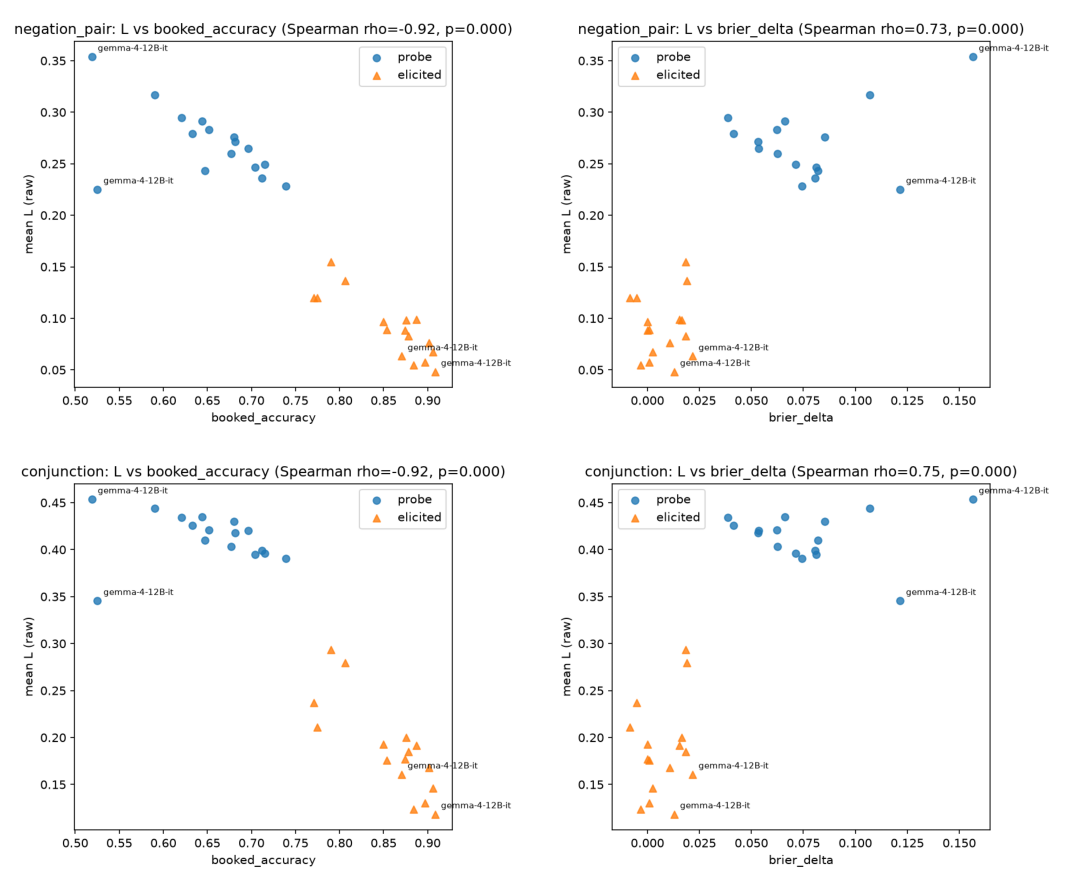

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
figs = [
    ("negation_pair", "booked_accuracy"), ("negation_pair", "brier_delta"),
    ("conjunction", "booked_accuracy"), ("conjunction", "brier_delta"),
]
for ax, (kind, correlate) in zip(axes.flat, figs):
    img = plt.imread(AGG / "figures" / f"correlate_{kind}_{correlate}.png")
    ax.imshow(img)
    ax.axis("off")
fig.tight_layout()
plt.show()

## 3. Methods and decisions

Every decision below was made on a ticket, closed with a resolution comment, and gisted on the map's
Decisions-so-far. This section synthesizes each one; follow the link for the full reasoning, alternatives
considered, and any research behind it.

### 3.1 Rate-of-loss formulation

[Which rate-of-loss formulation(s) do we compute?](.scratch/dutch-book/issues/01-rate-of-loss-formulation.md)
— Andrews' L is primary (the L∞ distance to coherence, [0,1]); SSK's ρ is a secondary column on conjunction
families only, since it adds no information on negation pairs (ρ = 2L/(1+2L) there). SSK's gambler-rate ψ is
never reported — it is unbounded as previsions approach 0 or 1, which uncalibrated probes do routinely. L
and ρ genuinely disagree on which of two previsions is worse once a family has more than one constituent
pair, so they are not interchangeable. Full LPs, closed-form oracles, and the thesis notation fix are on
branch `research/rate-of-loss-formulation`; see the patch,
[`.scratch/dutch-book/thesis-4.1.2-patch.md`](.scratch/dutch-book/thesis-4.1.2-patch.md).

### 3.2 Calibration

[Should probe previsions be calibrated before booking?](.scratch/dutch-book/issues/02-calibrating-probe-previsions.md)
— Calibration and coherence are separate properties (every source checked agrees); a probe that always
outputs ½ is trivially coherent at chance accuracy. Analytically, calibration can move L almost anywhere
between ≈0 and a scale-free "hard-label" limit, and can flip model rankings, so **the calibrated arm is a
labelled control, not the headline**. The control uses bias-free temperature scaling on the probe logit,
fitted by log-loss on a family-disjoint calibration split with the same statement mix as what's booked,
reported alongside the raw and T→0 (hard-label) rates. Full literature review and the numerical simulation
(including a constructed ranking flip) are on branch `research/calibrating-probe-previsions`.

### 3.3 Event-family construction

[Build the event families from the structured datasets](.scratch/dutch-book/issues/03-build-event-families.md)
— `Build_Event_Families.py` produced 547 negation pairs / 556 conjunction families for facts, and 500 / 546
for companies. Two facts conjunction families have inconsistent labels, both hinging on the contested "Nile
is the longest river" fact — excluded from (or reported separately from) the label-prevision control. About
half the negation-pair statements also sit verbatim in the probes' training data at the time of charting,
which drove the leakage-protocol decision next.

### 3.4 Probe leakage protocol

[How do we get probe previsions free of train/test leakage?](.scratch/dutch-book/issues/04-probe-leakage-protocol.md)
— **Domain swap**: a probe trained on the facts domain (plus six atomic datasets) books the companies
families, and vice versa, so every booked family is scored by a probe that never saw any statement from
that domain. Within-domain family-disjoint folds were rejected: negation pairs linked through shared
conjunctions form one giant connected component (439/547 facts pairs, 406/500 companies pairs — see the
live recomputation in §5 below), so there's no way to split within-domain without either a huge number of
folds or throwing away most of the data. The primary probe is linear logistic regression (matching thesis
§4.1.1); the existing MLP and an atomic-only probe are secondary arms. Rates are computed per seed and never
on averaged previsions (averaging always looks more coherent, since L is convex). The headline layer is
chosen by validation accuracy within the training domain, never on booked families.

### 3.5 Elicitation method

[How do we elicit previsions from model behavior?](.scratch/dutch-book/issues/05-elicitation-method.md) —
Next-token True/False logprobs are the primary method, each statement in its own prompt so the model never
sees other family members; stated 0–100 probabilities are a secondary arm for instruct models (a
20-family prototype found them near-binary and prone to flipping under negation). A model enters the
elicited arm only if its elicited accuracy on the training domain is ≥ 0.65 — the small legacy base models
tested in the prototype were at chance (SmolLM2-135M 0.49, OPT-1.3b 0.45) and would have contributed noise,
not signal.

### 3.6 Model list

[Which models do the experiments run on?](.scratch/dutch-book/issues/06-model-list.md) — Qwen2.5 at 1.5B,
7B and 14B (a 10× size sweep) plus Gemma 4 12B, each as a base + instruct pair, one L40 per model in bf16.
Gemma 4 was chosen over Qwen3.8 (which ships no base checkpoints, so couldn't pair with an instruct
counterpart) from primary sources: dense, Apache 2.0, ungated, with base and instruct checkpoints. The
legacy small models that failed the elicitation competence bar are dropped entirely.

### 3.7 Solver implementation

[Implement and validate the rate-of-loss solver](.scratch/dutch-book/issues/07-rate-of-loss-solver.md) —
`DutchBook.py`'s `rate_of_loss()` is covered by 10 tests against independent oracles (SSK's theorems, the
research counterexamples, closed forms checked on 300 random previsions, and the real families' own
labels). Label previsions give exactly 0 except on the two Nile-fact families. The random-prevision
ceilings — the reference point every real result below is read against — are mean L **0.162 on negation
pairs and 0.269 on conjunction families** (recomputed live in §4 below).

### 3.8 Probe previsions

[Produce probe previsions under the domain-swap protocol](.scratch/dutch-book/issues/08-probe-previsions.md)
— all 8 models' cluster runs completed cleanly, including the previously-untested Gemma 4 loader and
thinking-mode paths. Headline booked accuracies run 0.59–0.74 (companies) and 0.62–0.70 (facts) for the
Qwen2.5 models and base Gemma 4. `gemma-4-12B-it` is the exception: its linear probe never clears chance at
any of the 8 layers swept (val. accuracy 0.44–0.56), while the base checkpoint on the same statements/layers
reaches 0.87 — checked directly against the activations (no NaNs, no zero rows, normal variance), so this
looks like a real effect of instruction tuning on what a last-token linear probe can recover, not a pipeline
bug.

### 3.9 Elicited previsions

[Produce elicited previsions for every family statement](.scratch/dutch-book/issues/10-elicited-previsions.md)
— all 8 models' cluster runs completed cleanly; every model clears the 0.65 competence bar on every
method/template/domain combination (0.75–0.94), including `gemma-4-12B-it`.

### 3.10 Aggregation and comparison methodology

[How do per-family rates aggregate and compare across prevision sources?](.scratch/dutch-book/issues/11-aggregation-and-comparison.md)
— negation-pair families are mutually independent (verified: 0 duplicate base statements in facts, 1
accidental duplicate out of 500 in companies), but conjunction families are not: each is built from two
constituent pairs, and that reuse graph collapses into one giant connected component rather than many small
clusters (§5 recomputes this live). Comparisons therefore use a **pair-level (dyadic) bootstrap**: resample
negation pairs with replacement, give each conjunction family a bootstrap multiplicity equal to its two
parent pairs' resampled-copy co-occurrence count (B = 10,000, percentile CIs), with the same resampled
pair-pools reused across every model/source/arm so the probe-vs-elicited paired difference is valid.
Implemented in [`Aggregate_Rates.py`](Aggregate_Rates.py) (see
[its ticket](.scratch/dutch-book/issues/12-aggregation-implementation.md) for the 9 tests covering the
bootstrap mechanics); its output is what the tables and figures in this notebook load.

## 4. Full results

### Reference points

The random-prevision ceiling and label-prevision floor that every real result is read against
([§3.7](#3.7-Solver-implementation)):

In [7]:
reference = pd.read_csv(AGG / "reference_points.csv")
reference[reference.dataset == "pooled"]

,reference,dataset,family_shape,mean_L,n_families
4,ceiling_random,pooled,negation_pair,0.1620,1047
5,ceiling_random,pooled,conjunction,0.2692,1102
10,floor_labels,pooled,negation_pair,0.0000,1047
11,floor_labels,pooled,conjunction,0.0008,1102


In [8]:
# Live sanity check against the solver ticket's own numbers: recompute the pooled ceiling/floor
# directly from the control files rather than trusting the committed table.
control_random = pd.read_csv("results/dutch_book/control_random.csv")
control_labels = pd.read_csv("results/dutch_book/control_labels.csv")
for name, df in [("ceiling (random)", control_random), ("floor (labels)", control_labels)]:
    L = df[df.normalization == "L"]
    for kind in ["negation_pair", "conjunction"]:
        cell = L[L.kind == kind]
        print(f"{name:18s} {kind:14s} mean L = {cell.rate.mean():.4f}  (n={len(cell)})")

ceiling (random)   negation_pair  mean L = 0.1620  (n=1047)
ceiling (random)   conjunction    mean L = 0.2692  (n=1102)
floor (labels)     negation_pair  mean L = 0.0000  (n=1047)
floor (labels)     conjunction    mean L = 0.0008  (n=1102)


### Roll-up: mean and median L, raw previsions, per dataset × family shape × model × source

In [9]:
raw_rollup.sort_values(["dataset", "family_shape", "source", "model"])[
    ["dataset", "family_shape", "model", "source", "layer", "n_families", "mean_L", "median_L"]
]

,dataset,family_shape,model,source,layer,n_families,mean_L,median_L
14,companies,conjunction,Qwen2.5-1.5B,elicited,NaN,546,0.2109,0.2060
30,companies,conjunction,Qwen2.5-1.5B-Instruct,elicited,NaN,546,0.2935,0.3376
46,companies,conjunction,Qwen2.5-14B,elicited,NaN,546,0.1303,0.0780
62,companies,conjunction,Qwen2.5-14B-Instruct,elicited,NaN,546,0.1678,0.0005
78,companies,conjunction,Qwen2.5-7B,elicited,NaN,546,0.1235,0.1020
94,companies,conjunction,Qwen2.5-7B-Instruct,elicited,NaN,546,0.1847,0.0026
110,companies,conjunction,gemma-4-12B,elicited,NaN,546,0.1756,0.1800
126,companies,conjunction,gemma-4-12B-it,elicited,NaN,546,0.1607,0.0011
10,companies,conjunction,Qwen2.5-1.5B,probe,18.0000,546,0.4437,0.4918
26,companies,conjunction,Qwen2.5-1.5B-Instruct,probe,18.0000,546,0.4097,0.4815


### Distributions, with the ceiling and floor as reference lines

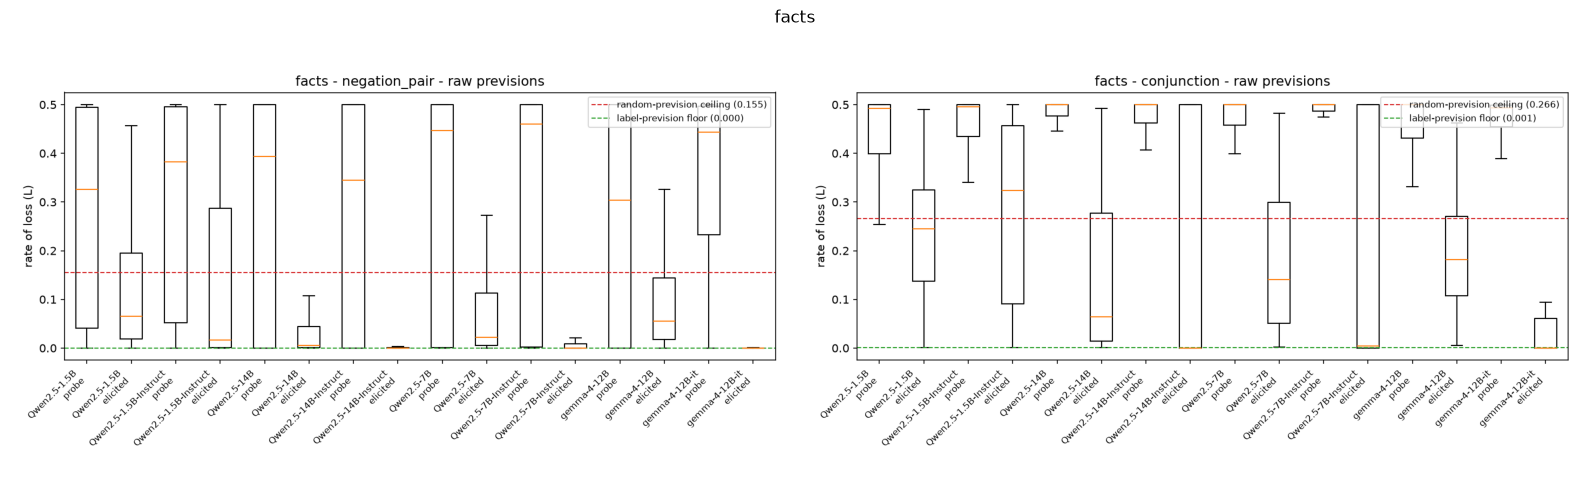

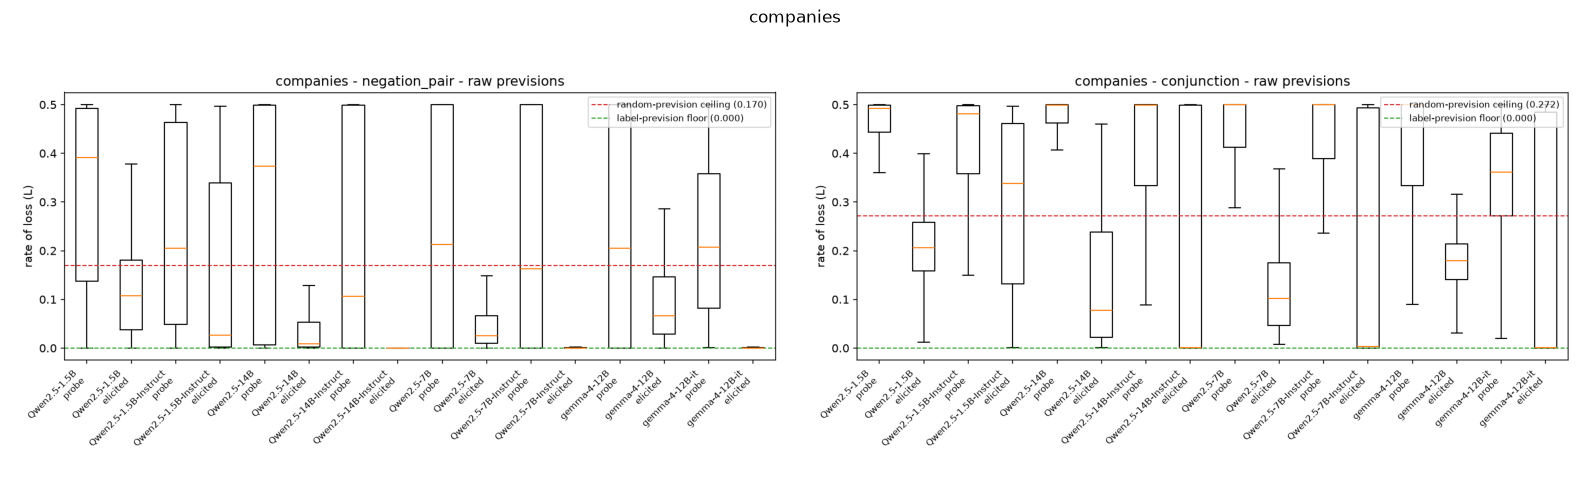

In [10]:
for dataset in ["facts", "companies"]:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for ax, kind in zip(axes, ["negation_pair", "conjunction"]):
        img = plt.imread(AGG / "figures" / f"box_{dataset}_{kind}.png")
        ax.imshow(img)
        ax.axis("off")
    fig.suptitle(dataset)
    fig.tight_layout()
    plt.show()

### Bootstrap confidence intervals (pair-level dyadic bootstrap, B = 10,000, 95% percentile CIs)

Per [the aggregation ticket](.scratch/dutch-book/issues/11-aggregation-and-comparison.md)'s decision: the
same resampled pair-pools are reused across every model/source/arm within a dataset × family shape, which is
what makes the paired-difference comparison in §2 valid.

In [11]:
bootstrap = pd.read_csv(AGG / "bootstrap_ci.csv")
bootstrap[~bootstrap.calibrated].sort_values(["dataset", "family_shape", "source", "model"])[
    ["dataset", "family_shape", "model", "source", "bootstrap_mean", "ci_lo", "ci_hi"]
]

,dataset,family_shape,model,source,bootstrap_mean,ci_lo,ci_hi
13,companies,conjunction,Qwen2.5-1.5B,elicited,0.2109,0.1971,0.2253
29,companies,conjunction,Qwen2.5-1.5B-Instruct,elicited,0.2934,0.2626,0.3237
45,companies,conjunction,Qwen2.5-14B,elicited,0.1300,0.1063,0.1567
61,companies,conjunction,Qwen2.5-14B-Instruct,elicited,0.1675,0.1263,0.2112
77,companies,conjunction,Qwen2.5-7B,elicited,0.1233,0.1077,0.1390
93,companies,conjunction,Qwen2.5-7B-Instruct,elicited,0.1844,0.1436,0.2272
109,companies,conjunction,gemma-4-12B,elicited,0.1756,0.1658,0.1852
125,companies,conjunction,gemma-4-12B-it,elicited,0.1605,0.1205,0.2035
12,companies,conjunction,Qwen2.5-1.5B,probe,0.4435,0.4251,0.4593
28,companies,conjunction,Qwen2.5-1.5B-Instruct,probe,0.4095,0.3860,0.4308


### Calibrated-arm paired differences

The calibrated arm is a labelled control, not the headline ([§3.2](#3.2-Calibration)) — included here for
completeness, not as the main comparison.

In [12]:
cal_diff = paired_diff[paired_diff.calibrated]
n_excl = cal_diff.excludes_zero.sum()
print(f"Calibrated-arm paired differences: {n_excl}/{len(cal_diff)} exclude zero.")
cal_diff[~cal_diff.excludes_zero].sort_values(["dataset", "family_shape", "model"])[
    ["dataset", "family_shape", "model", "mean_diff_probe_minus_elicited", "ci_lo", "ci_hi"]
]

Calibrated-arm paired differences: 29/32 exclude zero.


,dataset,family_shape,model,mean_diff_probe_minus_elicited,ci_lo,ci_hi
15,companies,conjunction,Qwen2.5-1.5B-Instruct,-0.0044,-0.0248,0.0165
13,companies,negation_pair,Qwen2.5-1.5B-Instruct,0.0030,-0.0074,0.0137
59,facts,conjunction,gemma-4-12B-it,0.0091,-0.0206,0.0365


### Conjunction polarity (descriptive, reporting-only — not a bootstrap stratum)

Conjunction polarity is a property of *which two pairs got combined and how*, not of a pair itself, so it
wasn't built into the resampling scheme ([§3.10](#3.10-Aggregation-and-comparison-methodology)). This is
purely descriptive.

In [13]:
polarity = pd.read_csv(AGG / "polarity_breakdown.csv")
polarity_raw = polarity  # polarity_rows() in Aggregate_Rates.py already restricts to the raw arm
(polarity_raw.groupby(["source", "polarity"])
 .apply(lambda g: (g.mean_L * g.n_families).sum() / g.n_families.sum(), include_groups=False)
 .rename("mean_L (families-weighted, all models pooled)").round(4))

source    polarity       
elicited  C1 neg / C2 neg   0.2038
          C1 neg / C2 pos   0.1810
          C1 pos / C2 neg   0.1905
          C1 pos / C2 pos   0.1703
probe     C1 neg / C2 neg   0.4149
          C1 neg / C2 pos   0.4103
          C1 pos / C2 neg   0.4171
          C1 pos / C2 pos   0.4130
Name: mean_L (families-weighted, all models pooled), dtype: float64

Probe rate of loss is essentially flat across all four polarities (0.41–0.42, negligible spread). Elicited
previsions show a real if modest spread — worse (more incoherent) when both conjuncts are negated, best when
neither is — but small enough that it doesn't change the headline story from §2.

## 5. Live verification: why conjunction families need a different bootstrap

[The aggregation ticket](.scratch/dutch-book/issues/11-aggregation-and-comparison.md) found that
conjunction families are not independent samples, because each is built from two constituent negation
pairs and pairs get reused across many conjunctions. Recomputed live here, directly from the event-family
files, rather than restating the ticket's numbers from memory.

In [14]:
import sys
sys.path.insert(0, ".")
from collections import Counter
from Aggregate_Rates import load_pair_graph, bootstrap_pair_counts, bootstrap_stat_negation_pairs, \
    bootstrap_stat_conjunctions

for dataset in ["facts", "companies"]:
    pair_ids, conj_pairs = load_pair_graph(f"event_families/{dataset}_families.json")

    # how many times each pair is reused across conjunction families
    reuse = Counter()
    for a, b in conj_pairs.values():
        reuse[a] += 1
        reuse[b] += 1
    reused_pairs = sum(1 for v in reuse.values() if v > 1)

    # connected components: nodes are pairs, edges are conjunction families
    parent = {}
    def find(x):
        while parent.get(x, x) != x:
            x = parent[x]
        return x
    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[ra] = rb
    for a, b in conj_pairs.values():
        parent.setdefault(a, a)
        parent.setdefault(b, b)
        union(a, b)
    component_sizes = Counter(find(x) for x in parent)
    giant = max(component_sizes.values())

    print(f"{dataset}: {len(pair_ids)} negation pairs, {len(conj_pairs)} conjunction families, "
          f"{len(reuse)} distinct pairs used in a conjunction")
    print(f"  {reused_pairs}/{len(reuse)} pairs reused in >=2 conjunction families "
          f"(max reuse: {max(reuse.values())})")
    print(f"  giant connected component: {giant}/{len(reuse)} of the used pairs are transitively linked")

facts: 547 negation pairs, 556 conjunction families, 477 distinct pairs used in a conjunction
  332/477 pairs reused in >=2 conjunction families (max reuse: 7)
  giant connected component: 439/477 of the used pairs are transitively linked
companies: 500 negation pairs, 546 conjunction families, 438 distinct pairs used in a conjunction
  313/438 pairs reused in >=2 conjunction families (max reuse: 11)
  giant connected component: 406/438 of the used pairs are transitively linked


"Cluster by negation pair" as a simple partition doesn't work here — there's effectively one blob, not many
small independent clusters. The resolution is a **pair-level (dyadic) bootstrap**: resample negation pairs
(the true independent unit) with replacement, and give each conjunction family a bootstrap multiplicity
equal to its two parent pairs' resampled-copy co-occurrence count. A small worked example, matching
`tests/test_aggregate_rates.py`:

In [15]:
# Toy graph: 3 pairs, 2 conjunction families (F0 = P0 & P1, F1 = P1 & P2)
toy_pair_ids = ["P0", "P1", "P2"]
toy_rates = {"P0": 0.1, "P1": 0.2, "P2": 0.3}
toy_conj_pairs = {"F0": (0, 1), "F1": (1, 2)}
toy_conj_rates = {"F0": 0.5, "F1": 0.7}

# One fixed (non-random) draw to make the mechanics legible:
# counts = [2, 1, 0] means P0's copy was drawn twice, P1's once, P2's zero times this round.
import numpy as np
fixed_counts = np.array([[2, 1, 0]])

pair_stat = bootstrap_stat_negation_pairs(fixed_counts, toy_rates, toy_pair_ids)
conj_stat = bootstrap_stat_conjunctions(fixed_counts, toy_conj_pairs, toy_conj_rates)
print(f"draw = P0 x2, P1 x1, P2 x0")
print(f"  negation-pair weighted mean = {pair_stat[0]:.4f}  (= (2*0.1 + 1*0.2) / 3)")
print(f"  F0 (P0 & P1) weight = 2*1 = 2 -> included;  F1 (P1 & P2) weight = 1*0 = 0 -> absent this draw")
print(f"  conjunction weighted mean   = {conj_stat[0]:.4f}  (= F0's rate alone, since F1 has zero weight)")

# Now a real bootstrap of B draws on the toy graph, for a percentile CI:
counts = bootstrap_pair_counts(n_pairs=3, draws=10000, seed=0)
pair_dist = bootstrap_stat_negation_pairs(counts, toy_rates, toy_pair_ids)
conj_dist = bootstrap_stat_conjunctions(counts, toy_conj_pairs, toy_conj_rates)
print(f"\nB=10000 bootstrap on the toy graph:")
print(f"  negation-pair stat: mean={pair_dist.mean():.4f}  95% CI=({np.percentile(pair_dist, 2.5):.4f}, "
      f"{np.percentile(pair_dist, 97.5):.4f})")
print(f"  conjunction stat:   mean={np.nanmean(conj_dist):.4f}  95% CI=({np.nanpercentile(conj_dist, 2.5):.4f}, "
      f"{np.nanpercentile(conj_dist, 97.5):.4f})")

draw = P0 x2, P1 x1, P2 x0
  negation-pair weighted mean = 0.1333  (= (2*0.1 + 1*0.2) / 3)
  F0 (P0 & P1) weight = 2*1 = 2 -> included;  F1 (P1 & P2) weight = 1*0 = 0 -> absent this draw
  conjunction weighted mean   = 0.5000  (= F0's rate alone, since F1 has zero weight)

B=10000 bootstrap on the toy graph:
  negation-pair stat: mean=0.1992  95% CI=(0.1000, 0.3000)
  conjunction stat:   mean=0.5986  95% CI=(0.5000, 0.7000)


This is exactly the mechanism `Aggregate_Rates.py` runs at full scale (B=10,000, real family graphs) to
produce every CI in §4 and every paired-difference test in §2 — see
[its 9 tests](tests/test_aggregate_rates.py) for the same mechanics checked against hand-computed values.

## 6. The `gemma-4-12B-it` split, in real statements

Two real families from `gemma-4-12B-it` on facts (headline arms: domain-swap linear probe at its headline
layer; logprob/t0 elicitation), read directly from the per-model previsions files. Saved as
[`results/dutch_book/aggregation/illustrative_examples.csv`](results/dutch_book/aggregation/illustrative_examples.csv)
so this is legible without the large cluster-local files.

In [16]:
pd.read_csv(AGG / "illustrative_examples.csv")

,model,dataset,family_shape,family_id,source,example,label,prevision,statement
0,gemma-4-12B-it,facts,negation_pair,neg_facts:pair:198,probe,worst probe violation,0,0.0000,The Earth is flat.
1,gemma-4-12B-it,facts,negation_pair,neg_facts:pair:198,probe,worst probe violation,1,0.0000,The Earth isn't flat.
2,gemma-4-12B-it,facts,negation_pair,neg_facts:pair:68,elicited,best elicited coherence,1,1.0000,The endocrine system regulates body functions ...
3,gemma-4-12B-it,facts,negation_pair,neg_facts:pair:68,elicited,best elicited coherence,0,0.0000,The endocrine system doesn't regulate body fun...


The probe's worst negation-pair violation on facts assigns **p ≈ 0 to both** "The Earth is flat" and "The
Earth isn't flat" — confident that neither will pay off, which is exactly the maximal-incoherence case
(d = |p(A)+p(¬A)−1| = 1, L = 0.5): a chance-level probe that has essentially stopped tracking content.
Elicited previsions on the *same model*, on a different family, get this exactly right: p ≈ 1 for the true
statement ("The endocrine system regulates body functions through hormones"), p ≈ 0 for its negation — L =
0, perfectly coherent. The gap in §2 isn't a statistical artifact of the aggregation; it shows up at the
level of individual statements.

## 7. Limitations

- **Two family shapes, two experiments, never pooled.** L divides a violation by the number of statements
  the violated constraint involves, so the same violation reads smaller in a 5-statement conjunction family
  than in a 2-statement pair ([§3.1](#3.1-Rate-of-loss-formulation)). Every comparison above respects this.
- **Two label-inconsistent conjunction families** (both facts, both hinging on the contested "Nile is the
  longest river" claim) are excluded from the label-prevision floor's headline number
  ([§3.3](#3.3-Event-family-construction)).
- **Headline probe is linear, and its layer is chosen once per (model, booked domain)** by validation
  accuracy on the training domain ([§3.4](#3.4-Probe-leakage-protocol)) — the MLP and atomic-only arms are
  secondary and not reported in the headline tables above; see `probe_rates/` for the full layer sweep.
- **The calibrated arm is a labelled control, not a better estimate of coherence** — calibration can move L
  almost anywhere and reorder models ([§3.2](#3.2-Calibration)), so its numbers in §4 should not be read as
  "the real" rate of loss.
- **Polarity and correlate findings are descriptive/observational**, not causal claims: the polarity spread
  in §4 is reporting-only by design, and the Spearman correlations in §2 record the accuracy/calibration
  relationship without claiming it explains the `gemma-4-12B-it` split (that's argued directly from the real
  statements in §6 instead).
- **8 models, one L40 each, one seed for the linear probe.** The MLP arm runs 5 seeds precisely because the
  linear probe doesn't; single-seed linear-probe numbers carry whatever seed variance a logistic regression
  fit has, unmeasured here.
- **Open-weights models only** ([out of scope on the map](.scratch/dutch-book/map.md)) — no claim is made
  about closed/API models, which have no activations to probe.

## 8. Thesis fixes

[Which rate-of-loss formulation(s) do we compute?](.scratch/dutch-book/issues/01-rate-of-loss-formulation.md)
found that thesis draft §4.1.2 (*AI: Agency and Representation*) has an open note asking whether its
notation and SSK's (1998) are equivalent, and a "Worked example: Dutch book-ability" subsection with no
example under it. Both are resolved and written up as literal, paste-ready replacement text in
[`.scratch/dutch-book/thesis-4.1.2-patch.md`](.scratch/dutch-book/thesis-4.1.2-patch.md):

- the reconciliation paragraph (SSK's ρ differs from Andrews' L only in how the stakes are normalized;
  they agree in ordering on negation pairs but not on conjunction families);
- three smaller notation fixes (the range of L, the (4.6) constraint, and (4.7)'s sign convention);
- a worked example built from the same p(A)=0.7/p(¬A)=0.5 case used in §5's background, plus the two
  conjunction-family counterexamples that show L and ρ disagreeing.

There is no LaTeX source for the thesis in this repository (only the compiled PDF in `references/`), so
that file is written to be pasted into the actual thesis source wherever it lives, not to be built here.

## 9. Where everything lives

| what | where |
|---|---|
| this write-up | `Dutch_Book_Write_Up.ipynb` (this file) |
| thesis fixes | `.scratch/dutch-book/thesis-4.1.2-patch.md` |
| the map and all 12 tickets | `.scratch/dutch-book/map.md`, `.scratch/dutch-book/issues/` |
| formulation research | branch `research/rate-of-loss-formulation` |
| calibration research | branch `research/calibrating-probe-previsions` |
| elicitation prototype | branch `prototype/elicitation-method` |
| event-family builder / families | `Build_Event_Families.py`, `event_families/*.json` |
| rate-of-loss solver + tests | `DutchBook.py`, `tests/test_dutch_book.py` |
| probe-previsions pipeline | `Generate_Activations.py`, `Train_Family_Probes.py`, `slurm/probe_previsions.sbatch` |
| elicited-previsions pipeline | `Elicit_Previsions.py`, `slurm/elicited_previsions.sbatch` |
| aggregation & comparison | `Aggregate_Rates.py`, `tests/test_aggregate_rates.py` |
| small committed results | `results/dutch_book/{probe,elicitation}_metrics/`, `results/dutch_book/aggregation/`, `results/dutch_book/control_{random,labels}.csv` |
| large cluster-local results (gitignored) | `activations/`, `results/dutch_book/previsions/`, `results/dutch_book/{probe,elicited}_rates/` |
| domain glossary | `CONTEXT.md` |